# Titanic Dataset Exploratory Data Analysis Assignment

**Dataset file required:** `Titanic-Dataset.csv`

This notebook completes all assignment requirements using Pandas, NumPy, Matplotlib, and Seaborn. It includes data loading, inspection, cleaning, feature engineering, Pandas Series/DataFrame operations, multi-indexing, visualizations, and EDA insights.

## Step 1: Import Required Libraries

This cell imports the libraries needed for data manipulation, numerical operations, and visualizations.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Titanic Dataset

The file must be uploaded to Colab with this exact name: `Titanic-Dataset.csv`.

In [2]:
# Load the Titanic dataset with error handling
try:
    df = pd.read_csv("Titanic-Dataset.csv")
    df_clean = df.copy()
    print("Dataset loaded successfully.")
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")

except FileNotFoundError:
    raise FileNotFoundError(
        "Titanic-Dataset.csv was not found. Upload the CSV file to the Colab Files panel with the exact name Titanic-Dataset.csv."
    )

except Exception as error:
    raise Exception(f"Unexpected error while loading the dataset: {error}")

Dataset loaded successfully.
Rows: 891
Columns: 12


## Step 3: Inspect the Data

The following cells use `head()`, `tail()`, `dtypes`, and `describe()` to understand the dataset structure.

In [3]:
# Display first five rows
print("First 5 rows:")
display(df_clean.head())

# Display last five rows
print("Last 5 rows:")
display(df_clean.tail())

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Last 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [4]:
# Display data types
print("Data types:")
display(df_clean.dtypes)

# Display descriptive statistics
print("Descriptive statistics:")
display(df_clean.describe(include="all"))

Data types:


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Descriptive statistics:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,1601,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [5]:
# Check missing values before cleaning
print("Missing values before cleaning:")
display(df_clean.isnull().sum())

Missing values before cleaning:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Step 4: Clean and Preprocess the Data

This section creates categorical features for passenger class and cabin, handles missing Age values, fills missing Embarked values, and creates a Family feature.

In [6]:
# Create categorical feature for Pclass
pclass_mapping = {
    1: "First Class",
    2: "Second Class",
    3: "Third Class"
}

df_clean["Pclass_Category"] = df_clean["Pclass"].map(pclass_mapping)

# Create categorical feature for Cabin availability
df_clean["Cabin_Category"] = np.where(
    df_clean["Cabin"].isnull(),
    "Cabin Not Available",
    "Cabin Available"
)

# Handle missing Age values using median age grouped by Sex and Pclass
try:
    df_clean["Age"] = df_clean.groupby(["Sex", "Pclass"])["Age"].transform(
        lambda x: x.fillna(x.median())
    )
    df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
    print("Missing Age values handled successfully.")
except Exception as error:
    print(f"Unexpected error while handling missing Age values: {error}")

# Handle missing Embarked values using mode
if df_clean["Embarked"].isnull().sum() > 0:
    df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# Create Family feature
# Family size includes passenger + siblings/spouses + parents/children
df_clean["Family_Size"] = df_clean["SibSp"] + df_clean["Parch"] + 1

df_clean["Family_Category"] = pd.cut(
    df_clean["Family_Size"],
    bins=[0, 1, 4, 20],
    labels=["Alone", "Small Family", "Large Family"]
)

print("New features created successfully.")
display(df_clean[["Pclass", "Pclass_Category", "Cabin", "Cabin_Category", "Age", "Family_Size", "Family_Category"]].head(10))

Missing Age values handled successfully.
New features created successfully.


,Pclass,Pclass_Category,Cabin,Cabin_Category,Age,Family_Size,Family_Category
0,3,Third Class,NaN,Cabin Not Available,22.0,2,Small Family
1,1,First Class,C85,Cabin Available,38.0,2,Small Family
2,3,Third Class,NaN,Cabin Not Available,26.0,1,Alone
3,1,First Class,C123,Cabin Available,35.0,2,Small Family
4,3,Third Class,NaN,Cabin Not Available,35.0,1,Alone
5,3,Third Class,NaN,Cabin Not Available,25.0,1,Alone
6,1,First Class,E46,Cabin Available,54.0,1,Alone
7,3,Third Class,NaN,Cabin Not Available,2.0,5,Large Family
8,3,Third Class,NaN,Cabin Not Available,27.0,3,Small Family
9,2,Second Class,NaN,Cabin Not Available,14.0,2,Small Family


In [7]:
# Check missing values after cleaning
print("Missing values after cleaning:")
display(df_clean.isnull().sum())

Missing values after cleaning:


PassengerId          0
Survived             0
Pclass               0
Name                 0
Sex                  0
Age                  0
SibSp                0
Parch                0
Ticket               0
Fare                 0
Cabin              687
Embarked             0
Pclass_Category      0
Cabin_Category       0
Family_Size          0
Family_Category      0
dtype: int64

### Cleaning Insight

Age had missing values, so it was filled using the median age by Sex and Pclass. This is better than using one overall median because age patterns differ by gender and passenger class. Cabin information had many missing values, so instead of deleting rows, a new Cabin availability category was created.

## Step 5: Identify Specific Data Points

This section finds passengers with the highest fare and passengers with the largest family size.

In [8]:
# Find passenger(s) with the highest fare
highest_fare = df_clean["Fare"].max()
highest_fare_passengers = df_clean[df_clean["Fare"] == highest_fare]

print(f"Highest fare paid: {highest_fare}")
display(highest_fare_passengers[["PassengerId", "Name", "Sex", "Pclass", "Fare", "Survived"]])

# Find passenger(s) with the largest family size
largest_family_size = df_clean["Family_Size"].max()
largest_family_passengers = df_clean[df_clean["Family_Size"] == largest_family_size]

print(f"Largest family size: {largest_family_size}")
display(largest_family_passengers[["PassengerId", "Name", "Sex", "Pclass", "SibSp", "Parch", "Family_Size", "Survived"]])

Highest fare paid: 512.3292


,PassengerId,Name,Sex,Pclass,Fare,Survived
258,259,"Ward, Miss. Anna",female,1,512.3292,1
679,680,"Cardeza, Mr. Thomas Drake Martinez",male,1,512.3292,1
737,738,"Lesurer, Mr. Gustave J",male,1,512.3292,1


Largest family size: 11


,PassengerId,Name,Sex,Pclass,SibSp,Parch,Family_Size,Survived
159,160,"Sage, Master. Thomas Henry",male,3,8,2,11,0
180,181,"Sage, Miss. Constance Gladys",female,3,8,2,11,0
201,202,"Sage, Mr. Frederick",male,3,8,2,11,0
324,325,"Sage, Mr. George John Jr",male,3,8,2,11,0
792,793,"Sage, Miss. Stella Anna",female,3,8,2,11,0
846,847,"Sage, Mr. Douglas Bullen",male,3,8,2,11,0
863,864,"Sage, Miss. Dorothy Edith ""Dolly""",female,3,8,2,11,0


## Step 6: Demonstrate Pandas Series and DataFrame Functionalities

This section creates and manipulates Series and DataFrames, including indexing and slicing operations.

In [9]:
# Create a Pandas Series from passenger ages
age_series = df_clean["Age"]
print("Age Series sample:")
display(age_series.head())

print("Age Series statistics:")
print(f"Mean Age: {age_series.mean():.2f}")
print(f"Median Age: {age_series.median():.2f}")
print(f"Minimum Age: {age_series.min():.2f}")
print(f"Maximum Age: {age_series.max():.2f}")

Age Series sample:


0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64

Age Series statistics:
Mean Age: 29.11
Median Age: 26.00
Minimum Age: 0.42
Maximum Age: 80.00


In [10]:
# Create a smaller DataFrame for demonstration
passenger_summary = df_clean[["PassengerId", "Name", "Sex", "Age", "Pclass", "Survived", "Fare"]].copy()

print("Passenger Summary DataFrame:")
display(passenger_summary.head())

# Indexing with loc
print("Rows 0 to 4 using loc:")
display(passenger_summary.loc[0:4, ["Name", "Age", "Survived"]])

# Slicing with iloc
print("First 5 rows and first 4 columns using iloc:")
display(passenger_summary.iloc[0:5, 0:4])

# Filter passengers older than 60
older_passengers = passenger_summary[passenger_summary["Age"] > 60]
print("Passengers older than 60:")
display(older_passengers.head())

Passenger Summary DataFrame:


,PassengerId,Name,Sex,Age,Pclass,Survived,Fare
0,1,"Braund, Mr. Owen Harris",male,22.0,3,0,7.2500
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,1,71.2833
2,3,"Heikkinen, Miss. Laina",female,26.0,3,1,7.9250
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,1,53.1000
4,5,"Allen, Mr. William Henry",male,35.0,3,0,8.0500


Rows 0 to 4 using loc:


,Name,Age,Survived
0,"Braund, Mr. Owen Harris",22.0,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1
2,"Heikkinen, Miss. Laina",26.0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1
4,"Allen, Mr. William Henry",35.0,0


First 5 rows and first 4 columns using iloc:


,PassengerId,Name,Sex,Age
0,1,"Braund, Mr. Owen Harris",male,22.0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0
2,3,"Heikkinen, Miss. Laina",female,26.0
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0
4,5,"Allen, Mr. William Henry",male,35.0


Passengers older than 60:


,PassengerId,Name,Sex,Age,Pclass,Survived,Fare
33,34,"Wheadon, Mr. Edward H",male,66.0,2,0,10.5000
54,55,"Ostby, Mr. Engelhart Cornelius",male,65.0,1,0,61.9792
96,97,"Goldschmidt, Mr. George B",male,71.0,1,0,34.6542
116,117,"Connors, Mr. Patrick",male,70.5,3,0,7.7500
170,171,"Van der hoef, Mr. Wyckoff",male,61.0,1,0,33.5000


## Step 7: Multi-Indexing

This section creates a multi-index DataFrame showing survival rates by Sex and Pclass.

In [11]:
# Create multi-index DataFrame of survival rates by Sex and Pclass
survival_multi_index = df_clean.groupby(["Sex", "Pclass"])["Survived"].mean().to_frame()
survival_multi_index.rename(columns={"Survived": "Survival_Rate"}, inplace=True)
survival_multi_index["Survival_Rate_Percentage"] = survival_multi_index["Survival_Rate"] * 100

print("Survival rates by Sex and Pclass:")
display(survival_multi_index)

Survival rates by Sex and Pclass:


Survival_Rate  Survival_Rate_Percentage
Sex    Pclass                                         
female 1            0.968085                 96.808511
       2            0.921053                 92.105263
       3            0.500000                 50.000000
male   1            0.368852                 36.885246
       2            0.157407                 15.740741
       3            0.135447                 13.544669

### Multi-Index Insight

The multi-index table shows that survival rates differed significantly by both gender and passenger class. Female passengers had higher survival rates than male passengers, and first-class passengers generally had better survival outcomes.

## Step 8: Visualization - Histogram of Passenger Ages

Unexpected error while creating age histogram: Invalid RGBA argument: None


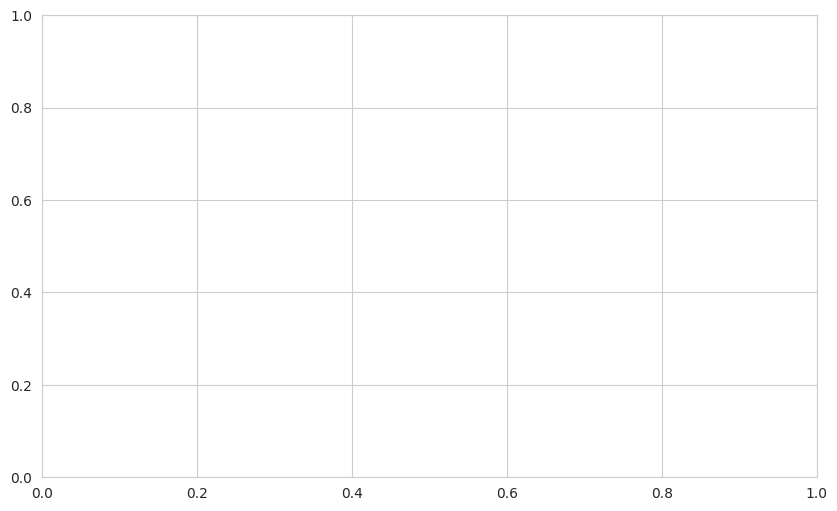

In [12]:
# Histogram of passenger ages
try:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_clean["Age"], bins=30, kde=True)
    plt.title("Histogram of Passenger Ages")
    plt.xlabel("Age")
    plt.ylabel("Number of Passengers")
    plt.show()
except Exception as error:
    print(f"Unexpected error while creating age histogram: {error}")

### Age Histogram Insight

Most Titanic passengers were young adults, with a large concentration between approximately 20 and 40 years old. There were fewer elderly passengers and fewer very young children compared to adults.

## Step 9: Visualization - Survival Rates by Passenger Class

Unexpected error while creating survival rate bar plot: Invalid RGBA argument: None


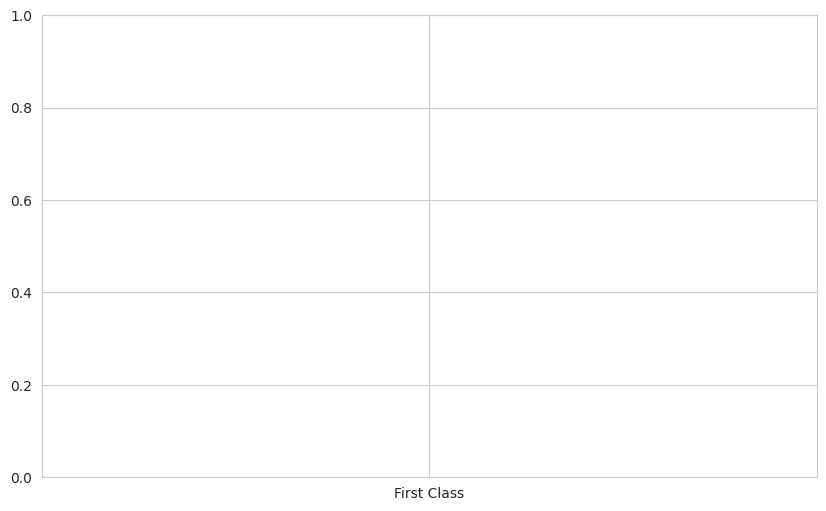

In [13]:
# Bar plot of survival rates by passenger class
try:
    survival_by_class = df_clean.groupby("Pclass_Category")["Survived"].mean().reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=survival_by_class, x="Pclass_Category", y="Survived")
    plt.title("Survival Rates by Passenger Class")
    plt.xlabel("Passenger Class")
    plt.ylabel("Survival Rate")
    plt.ylim(0, 1)
    plt.show()

    display(survival_by_class)
except Exception as error:
    print(f"Unexpected error while creating survival rate bar plot: {error}")

### Passenger Class Insight

First-class passengers had the highest survival rate, followed by second-class passengers, while third-class passengers had the lowest survival rate. This suggests that socio-economic status and access to lifeboats may have influenced survival outcomes.

## Step 10: Visualization - Correlation Heatmap

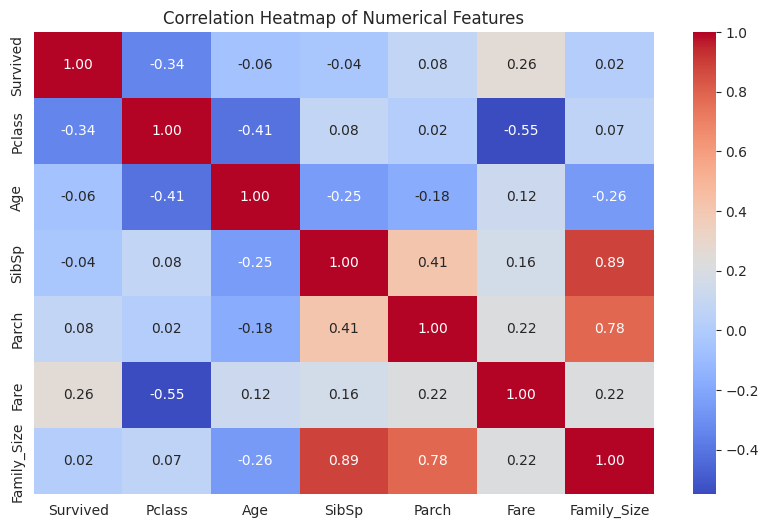

In [14]:
# Heatmap of correlations between numerical features
try:
    numeric_columns = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "Family_Size"]
    correlation_matrix = df_clean[numeric_columns].corr()

    plt.figure(figsize=(10, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap of Numerical Features")
    plt.show()
except Exception as error:
    print(f"Unexpected error while creating correlation heatmap: {error}")

### Correlation Insight

Fare shows a positive relationship with survival, while Pclass has a negative relationship with survival because lower class numbers represent higher passenger classes. This indicates that passengers in higher classes and passengers who paid higher fares were more likely to survive.

## Step 11: Visualization - Pair Plot of Selected Features

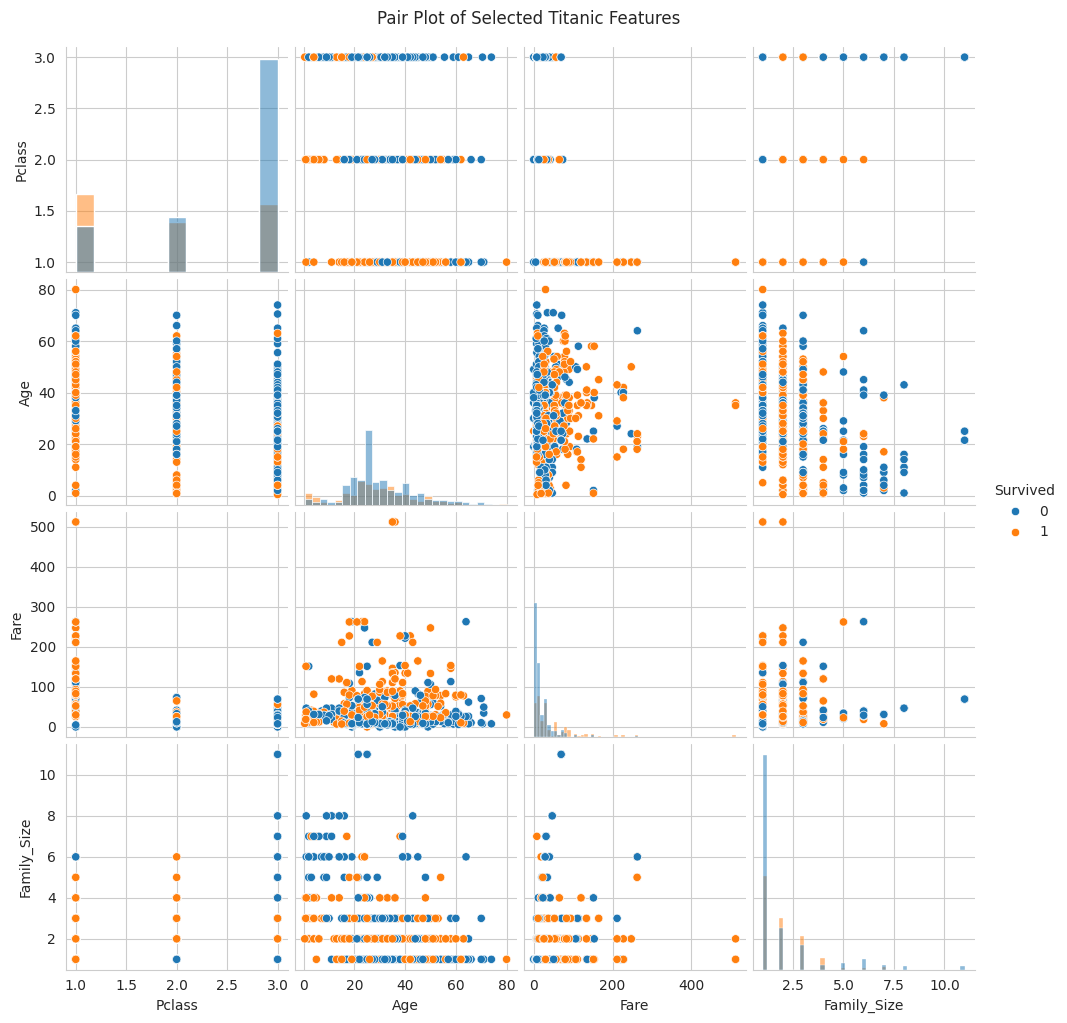

In [15]:
# Pair plot of selected features
try:
    selected_features = df_clean[["Survived", "Pclass", "Age", "Fare", "Family_Size"]].copy()
    sns.pairplot(selected_features, hue="Survived", diag_kind="hist")
    plt.suptitle("Pair Plot of Selected Titanic Features", y=1.02)
    plt.show()
except Exception as error:
    print(f"Unexpected error while creating pair plot: {error}")

### Pair Plot Insight

The pair plot helps compare relationships between Age, Fare, Family Size, Passenger Class, and Survival. Fare and Pclass appear to show clearer differences between survivors and non-survivors than Age alone.

## Step 12: Analyze Survival Rates by Sex and Passenger Class

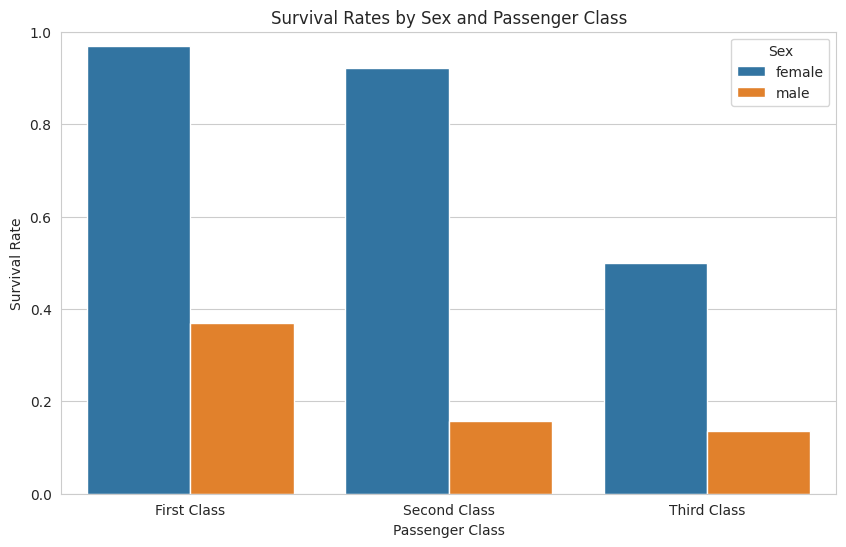

,Sex,Pclass_Category,Survived
0,female,First Class,0.968085
1,female,Second Class,0.921053
2,female,Third Class,0.500000
3,male,First Class,0.368852
4,male,Second Class,0.157407
5,male,Third Class,0.135447


In [16]:
# Analyze survival rates by Sex and Passenger Class
try:
    survival_sex_class = df_clean.groupby(["Sex", "Pclass_Category"])["Survived"].mean().reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=survival_sex_class, x="Pclass_Category", y="Survived", hue="Sex")
    plt.title("Survival Rates by Sex and Passenger Class")
    plt.xlabel("Passenger Class")
    plt.ylabel("Survival Rate")
    plt.ylim(0, 1)
    plt.legend(title="Sex")
    plt.show()

    display(survival_sex_class)
except Exception as error:
    print(f"Unexpected error while analyzing survival by sex and class: {error}")

### Survival by Sex and Class Insight

Female passengers had significantly higher survival rates across all passenger classes compared to male passengers. First-class passengers also had stronger survival outcomes. This supports the historical pattern of women and higher-class passengers having better chances of survival.

## Step 13: Analyze Age Distribution Using a Box Plot

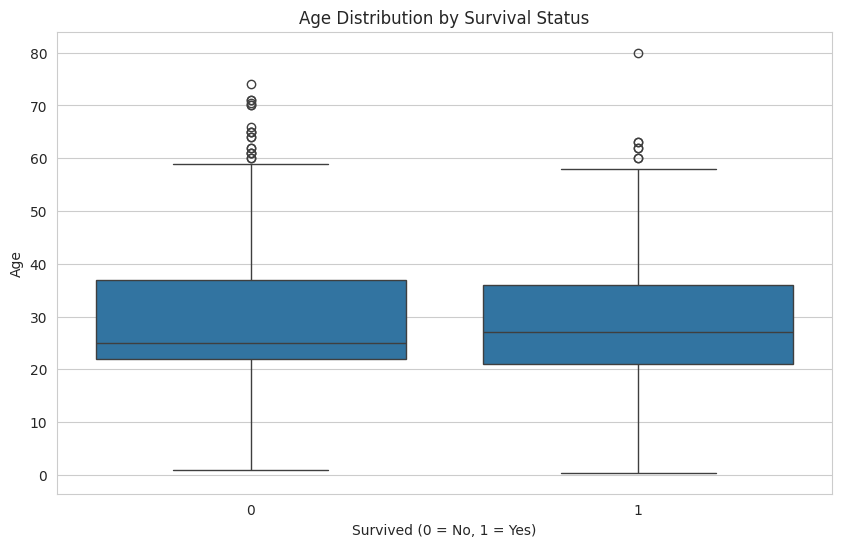

In [17]:
# Box plot of age distribution by survival status
try:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_clean, x="Survived", y="Age")
    plt.title("Age Distribution by Survival Status")
    plt.xlabel("Survived (0 = No, 1 = Yes)")
    plt.ylabel("Age")
    plt.show()
except Exception as error:
    print(f"Unexpected error while creating age box plot: {error}")

### Age Box Plot Insight

The age distribution of survivors and non-survivors overlaps significantly, meaning age alone was not the strongest survival predictor. However, younger passengers may have had some advantage, especially children.

## Step 14: Analyze Fare Distribution Using a Violin Plot

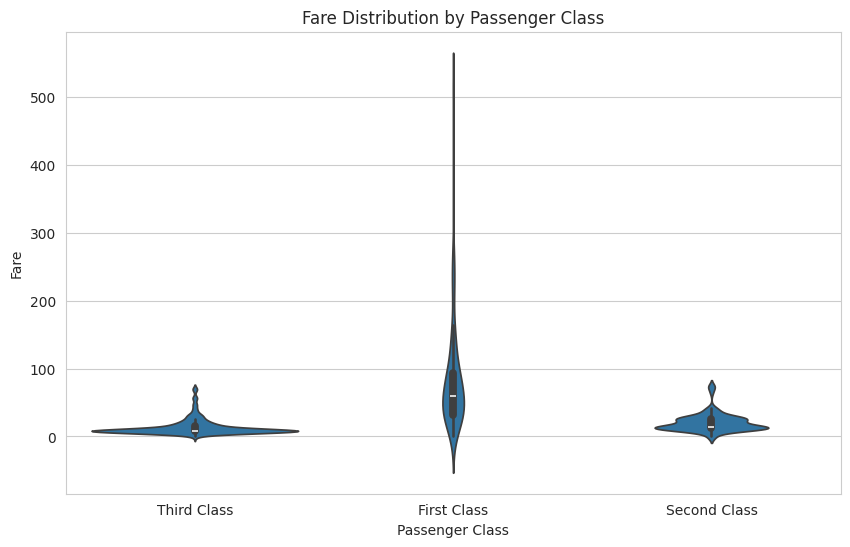

In [18]:
# Violin plot of fare distribution by passenger class
try:
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df_clean, x="Pclass_Category", y="Fare")
    plt.title("Fare Distribution by Passenger Class")
    plt.xlabel("Passenger Class")
    plt.ylabel("Fare")
    plt.show()
except Exception as error:
    print(f"Unexpected error while creating fare violin plot: {error}")

### Fare Distribution Insight

First-class passengers generally paid much higher fares than second- and third-class passengers. The fare distribution also contains outliers, especially in first class, where some passengers paid very high fares.

## Step 15: Final EDA Summary

The Titanic dataset shows that survival was strongly influenced by sex, passenger class, and fare. Female passengers had much higher survival rates than male passengers. First-class passengers also had higher survival rates than second- and third-class passengers. Fare had a positive relationship with survival, while third-class passengers had a lower survival rate. Age was useful for analysis, but it did not separate survivors and non-survivors as strongly as sex and passenger class. Family size also provided useful information because passengers traveling alone or in very large families may have faced different survival challenges.

Overall, the analysis demonstrates how Pandas can be used for data cleaning, feature engineering, grouping, multi-indexing, and exploratory data analysis, while Matplotlib and Seaborn help communicate insights visually.

## Step 16: Save the Cleaned Dataset

This creates a cleaned CSV file that can also be uploaded to GitHub with the notebook.

In [19]:
# Save cleaned dataset
try:
    df_clean.to_csv("Titanic_Cleaned.csv", index=False)
    print("Cleaned dataset saved successfully as Titanic_Cleaned.csv")
except Exception as error:
    print(f"Unexpected error while saving cleaned dataset: {error}")

Cleaned dataset saved successfully as Titanic_Cleaned.csv
